# Блок 1: Импорт необходимых библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text, plot_tree
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score,
                             precision_score, recall_score, f1_score)
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


# Блок 2: Загрузка датасетов

In [2]:
try:
    # Загрузка датасета Gun Violence
    gun_data = pd.read_csv('gun-violence-data.csv')
    
    # Загрузка датасета Anime
    anime_data = pd.read_csv('anime.csv')
    
    print("Датасеты успешно загружены")
    print(f"Gun Violence Data: {gun_data.shape}")
    print(f"Anime Data: {anime_data.shape}")
    
except FileNotFoundError as e:
    print(f"Ошибка загрузки файлов: {e}")
    print("Убедитесь, что файлы находятся в той же директории")

Датасеты успешно загружены
Gun Violence Data: (239677, 29)
Anime Data: (12294, 7)


# Блок 3: Предобработка данных для регрессии (Gun Violence)

Размер датасета для регрессии: (10000, 6)
Распределение целевой переменной:
count    10000.000000
mean         0.695900
std          0.832642
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max         25.000000
Name: total_victims, dtype: float64


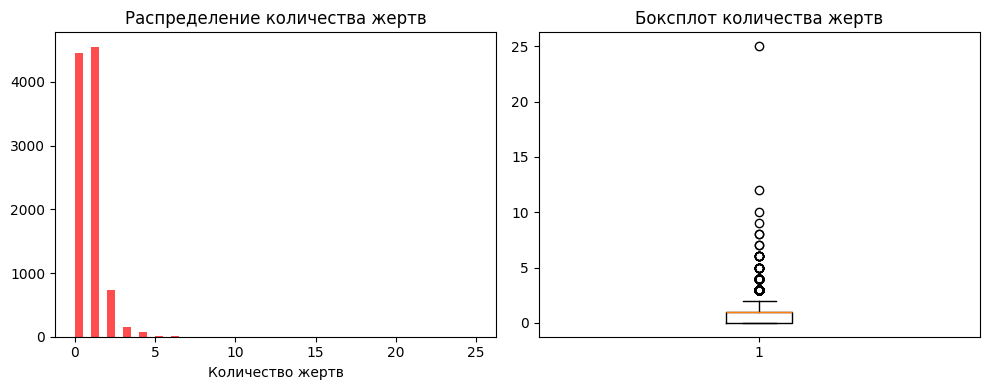

In [3]:
# Создание целевой переменной
gun_data['total_victims'] = gun_data['n_killed'] + gun_data['n_injured']

# Удаление неиспользуемых столбцов
used_columns_reg = ['latitude', 'longitude', 'n_guns_involved', 'state', 'city_or_county', 'total_victims']
gun_data_reduced = gun_data[used_columns_reg].copy()

# Удаление строк с пропущенными значениями
gun_data_clean = gun_data_reduced.dropna()

# Ограничим данные для ускорения (опционально)
if gun_data_clean.shape[0] > 10000:
    gun_data_clean = gun_data_clean.sample(n=10000, random_state=42, replace=False)

print(f"Размер датасета для регрессии: {gun_data_clean.shape}")
print(f"Распределение целевой переменной:")
print(gun_data_clean['total_victims'].describe())

# Визуализация распределения
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(gun_data_clean['total_victims'], bins=50, alpha=0.7, color='red')
plt.title('Распределение количества жертв')
plt.xlabel('Количество жертв')

plt.subplot(1, 2, 2)
plt.boxplot(gun_data_clean['total_victims'])
plt.title('Боксплот количества жертв')
plt.tight_layout()
plt.show()

# Блок 4: Предобработка данных для классификации (Anime)

Размер датасета для классификации: (5000, 5)
Распределение типов аниме:
type
TV         1706
OVA        1492
Movie      1022
Special     780
Name: count, dtype: int64


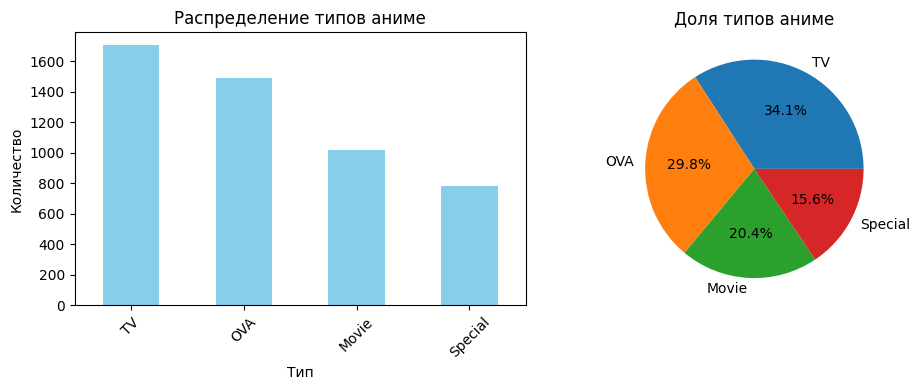

In [4]:
# Удаление неиспользуемых столбцов
used_columns_clf = ['episodes', 'rating', 'members', 'genre', 'type']
anime_data_reduced = anime_data[used_columns_clf].copy()

# Удаление строк с пропущенными значениями
anime_data_clean = anime_data_reduced.dropna()

# Оставляем основные типы
main_types = ['TV', 'Movie', 'OVA', 'Special']
anime_data_clean = anime_data_clean[anime_data_clean['type'].isin(main_types)]

# Ограничим данные для ускорения (опционально)
if anime_data_clean.shape[0] > 5000:
    anime_data_clean = anime_data_clean.sample(n=5000, random_state=42, replace=False)

print(f"Размер датасета для классификации: {anime_data_clean.shape}")
print(f"Распределение типов аниме:")
type_counts = anime_data_clean['type'].value_counts()
print(type_counts)

# Визуализация распределения классов
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
type_counts.plot(kind='bar', color='skyblue')
plt.title('Распределение типов аниме')
plt.xlabel('Тип')
plt.ylabel('Количество')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%')
plt.title('Доля типов аниме')
plt.tight_layout()
plt.show()

# Блок 5: Подготовка признаков для регрессии

In [5]:
# Разделение на признаки и целевую переменную
features_reg = ['latitude', 'longitude', 'n_guns_involved', 'state', 'city_or_county']
target_reg = 'total_victims'

X_reg = gun_data_clean[features_reg].copy()
y_reg = gun_data_clean[target_reg]

# Кодирование категориальных признаков для деревьев
label_encoder_state = LabelEncoder()
label_encoder_city = LabelEncoder()

X_reg['state_encoded'] = label_encoder_state.fit_transform(X_reg['state'].fillna('Unknown'))
X_reg['city_encoded'] = label_encoder_city.fit_transform(X_reg['city_or_county'].fillna('Unknown'))

# Выбираем закодированные признаки
X_reg_encoded = X_reg[['latitude', 'longitude', 'n_guns_involved', 'state_encoded', 'city_encoded']]

# Заполнение пропущенных значений
imputer_reg = SimpleImputer(strategy='median')
X_reg_imputed = pd.DataFrame(imputer_reg.fit_transform(X_reg_encoded), 
                            columns=X_reg_encoded.columns)

# Для деревьев масштабирование не обязательно, но можем оставить для других моделей
scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg_imputed)

# Разделение на train/test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)

print(f"Размеры выборок для регрессии:")
print(f"Train: {X_train_reg.shape}, Test: {X_test_reg.shape}")
print(f"Количество признаков: {X_train_reg.shape[1]}")

Размеры выборок для регрессии:
Train: (8000, 5), Test: (2000, 5)
Количество признаков: 5


# Блок 6: Подготовка признаков для классификации

In [6]:
# Разделение на признаки и целевую переменную
features_clf = ['episodes', 'rating', 'members', 'genre']
target_clf = 'type'

X_clf = anime_data_clean[features_clf].copy()
y_clf = anime_data_clean[target_clf]

# Обработка признаков
X_clf['episodes'] = pd.to_numeric(X_clf['episodes'], errors='coerce')
X_clf['main_genre'] = X_clf['genre'].str.split(',').str[0].fillna('Unknown')

# Кодирование категориальных признаков
label_encoder_genre = LabelEncoder()
X_clf['main_genre_encoded'] = label_encoder_genre.fit_transform(X_clf['main_genre'])

# Выбор финальных признаков
X_clf_processed = X_clf[['episodes', 'rating', 'members', 'main_genre_encoded']]

# Заполнение пропущенных значений
imputer_clf = SimpleImputer(strategy='median')
X_clf_imputed = pd.DataFrame(imputer_clf.fit_transform(X_clf_processed), 
                            columns=X_clf_processed.columns)

# Для деревьев масштабирование не обязательно
scaler_clf = StandardScaler()
X_clf_scaled = scaler_clf.fit_transform(X_clf_imputed)

# Кодирование целевой переменной
label_encoder_target = LabelEncoder()
y_clf_encoded = label_encoder_target.fit_transform(y_clf)

# Разделение на train/test
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_scaled, y_clf_encoded, test_size=0.2, random_state=42, stratify=y_clf_encoded
)

print(f"Размеры выборок для классификации:")
print(f"Train: {X_train_clf.shape}, Test: {X_test_clf.shape}")
print(f"Количество классов: {len(label_encoder_target.classes_)}")
print(f"Классы: {label_encoder_target.classes_}")

Размеры выборок для классификации:
Train: (4000, 4), Test: (1000, 4)
Количество классов: 4
Классы: ['Movie' 'OVA' 'Special' 'TV']


# Блок 7: Бейзлайн модели решающих деревьев

Бейзлайн модели решающих деревьев обучены


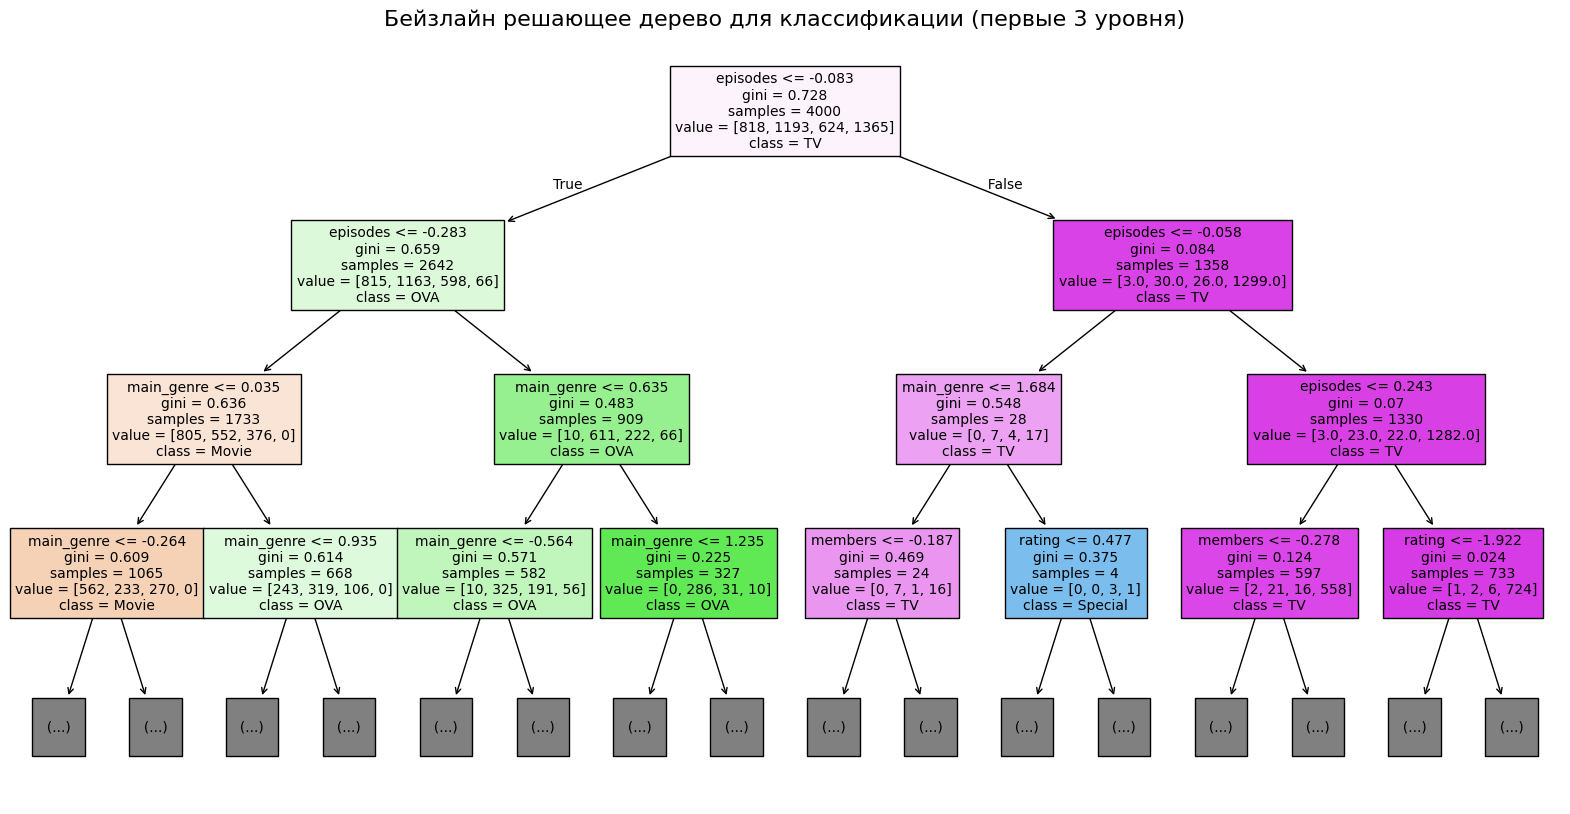

In [7]:
# Решающее дерево для регрессии
tree_reg_baseline = DecisionTreeRegressor(random_state=42)
tree_reg_baseline.fit(X_train_reg, y_train_reg)
y_pred_reg_baseline = tree_reg_baseline.predict(X_test_reg)

# Решающее дерево для классификации
tree_clf_baseline = DecisionTreeClassifier(random_state=42)
tree_clf_baseline.fit(X_train_clf, y_train_clf)
y_pred_clf_baseline = tree_clf_baseline.predict(X_test_clf)

print("Бейзлайн модели решающих деревьев обучены")

# Визуализация одного из деревьев (классификация)
plt.figure(figsize=(20, 10))
plot_tree(tree_clf_baseline, 
          feature_names=['episodes', 'rating', 'members', 'main_genre'],
          class_names=label_encoder_target.classes_,
          filled=True, 
          max_depth=3,
          fontsize=10)
plt.title("Бейзлайн решающее дерево для классификации (первые 3 уровня)", fontsize=16)
plt.show()

# Блок 8: Оценка качества бейзлайн моделей


--- РЕШАЮЩЕЕ ДЕРЕВО РЕГРЕССИИ (Gun Violence) ---
MAE: 0.6304
RMSE: 0.9894
R² Score: -0.7010

Глубина дерева регрессии: 41
Количество листьев дерева регрессии: 3370

--- РЕШАЮЩЕЕ ДЕРЕВО КЛАССИФИКАЦИИ (Anime) ---
Accuracy: 0.6790
Precision: 0.6836
Recall: 0.6790
F1-Score: 0.6811

Глубина дерева классификации: 29
Количество листьев дерева классификации: 1032

Classification Report:
              precision    recall  f1-score   support

       Movie       0.55      0.59      0.57       204
         OVA       0.64      0.63      0.63       299
     Special       0.33      0.34      0.34       156
          TV       0.96      0.94      0.95       341

    accuracy                           0.68      1000
   macro avg       0.62      0.62      0.62      1000
weighted avg       0.68      0.68      0.68      1000



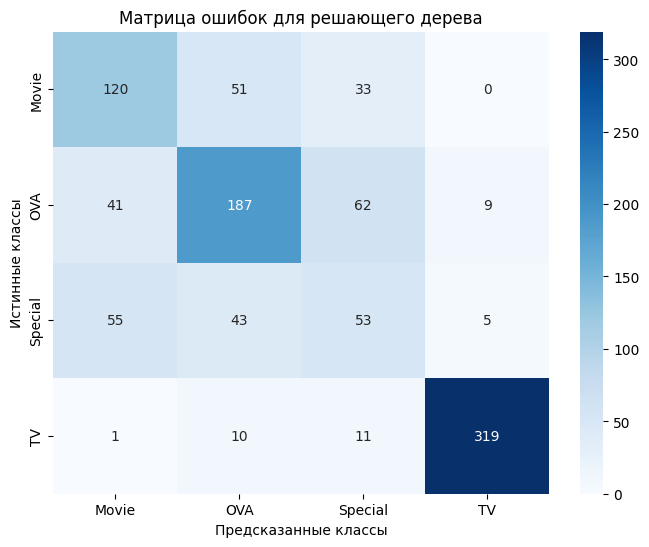

In [8]:
print("\n--- РЕШАЮЩЕЕ ДЕРЕВО РЕГРЕССИИ (Gun Violence) ---")
mae_baseline = mean_absolute_error(y_test_reg, y_pred_reg_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_baseline))
r2_baseline = r2_score(y_test_reg, y_pred_reg_baseline)

print(f"MAE: {mae_baseline:.4f}")
print(f"RMSE: {rmse_baseline:.4f}")
print(f"R² Score: {r2_baseline:.4f}")

print(f"\nГлубина дерева регрессии: {tree_reg_baseline.get_depth()}")
print(f"Количество листьев дерева регрессии: {tree_reg_baseline.get_n_leaves()}")

print("\n--- РЕШАЮЩЕЕ ДЕРЕВО КЛАССИФИКАЦИИ (Anime) ---")
accuracy_baseline = accuracy_score(y_test_clf, y_pred_clf_baseline)
precision_baseline = precision_score(y_test_clf, y_pred_clf_baseline, average='weighted')
recall_baseline = recall_score(y_test_clf, y_pred_clf_baseline, average='weighted')
f1_baseline = f1_score(y_test_clf, y_pred_clf_baseline, average='weighted')

print(f"Accuracy: {accuracy_baseline:.4f}")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall: {recall_baseline:.4f}")
print(f"F1-Score: {f1_baseline:.4f}")

print(f"\nГлубина дерева классификации: {tree_clf_baseline.get_depth()}")
print(f"Количество листьев дерева классификации: {tree_clf_baseline.get_n_leaves()}")

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf_baseline, 
                          target_names=label_encoder_target.classes_))

# Матрица ошибок
cm = confusion_matrix(y_test_clf, y_pred_clf_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder_target.classes_, 
            yticklabels=label_encoder_target.classes_)
plt.title('Матрица ошибок для решающего дерева')
plt.ylabel('Истинные классы')
plt.xlabel('Предсказанные классы')
plt.show()

# Формулировка гипотез для улучшения

## ГИПОТЕЗЫ ДЛЯ РЕГРЕССИИ:
1. Ограничение глубины дерева для избежания переобучения
2. Настройка минимального количества образцов в листе
3. Использование минимального снижения неопределенности для разделения
4. Применение ансамблевых методов (Random Forest)

## ГИПОТЕЗЫ ДЛЯ КЛАССИФИКАЦИИ:
1. Балансировка классов (class_weight)
2. Ограничение максимальной глубины
3. Настройка минимального количества образцов для разделения
4. Использование критерия Джини vs энтропия
5. Применение ансамблевых методов (Random Forest)

## ОБЩИЕ ГИПОТЕЗЫ:
1. Отбор важных признаков
2. Использование кросс-валидации для подбора гиперпараметров
3. Применение регуляризации деревьев


# Блок 9: Проверка гипотез - подбор гиперпараметров для регрессии

In [9]:
# Параметры для решающего дерева регрессии
param_grid_tree_reg = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['auto', 'sqrt', 'log2']
}

print("Подбор гиперпараметров для дерева регрессии...")
tree_reg_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_tree_reg,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
tree_reg_grid.fit(X_train_reg, y_train_reg)

print(f"Лучшие параметры для дерева регрессии: {tree_reg_grid.best_params_}")
print(f"Лучший RMSE: {np.sqrt(-tree_reg_grid.best_score_):.4f}")

# Проверка Random Forest для регрессии
print("\nПроверка Random Forest для регрессии...")
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_reg)

rf_mae = mean_absolute_error(y_test_reg, y_pred_rf_reg)
rf_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))
rf_r2 = r2_score(y_test_reg, y_pred_rf_reg)

print(f"Random Forest MAE: {rf_mae:.4f}")
print(f"Random Forest RMSE: {rf_rmse:.4f}")
print(f"Random Forest R²: {rf_r2:.4f}")

Подбор гиперпараметров для дерева регрессии...


Лучшие параметры для дерева регрессии: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10}
Лучший RMSE: 0.8393

Проверка Random Forest для регрессии...
Random Forest MAE: 0.5626
Random Forest RMSE: 0.7615
Random Forest R²: -0.0076


# Блок 10: Проверка гипотез - подбор гиперпараметров для классификации

In [10]:
# Параметры для решающего дерева классификации
param_grid_tree_clf = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

print("Подбор гиперпараметров для дерева классификации...")
tree_clf_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree_clf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
tree_clf_grid.fit(X_train_clf, y_train_clf)

print(f"Лучшие параметры для дерева классификации: {tree_clf_grid.best_params_}")
print(f"Лучшая точность: {tree_clf_grid.best_score_:.4f}")

# Проверка Random Forest для классификации
print("\nПроверка Random Forest для классификации...")
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_clf, y_train_clf)
y_pred_rf_clf = rf_clf.predict(X_test_clf)

rf_accuracy = accuracy_score(y_test_clf, y_pred_rf_clf)
rf_precision = precision_score(y_test_clf, y_pred_rf_clf, average='weighted')
rf_f1 = f1_score(y_test_clf, y_pred_rf_clf, average='weighted')

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest Precision: {rf_precision:.4f}")
print(f"Random Forest F1: {rf_f1:.4f}")

Подбор гиперпараметров для дерева классификации...
Лучшие параметры для дерева классификации: {'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Лучшая точность: 0.7253

Проверка Random Forest для классификации...
Random Forest Accuracy: 0.7170
Random Forest Precision: 0.7109
Random Forest F1: 0.7134


# Блок 11: Улучшенные модели с подобранными гиперпараметрами

Улучшенные модели решающих деревьев обучены


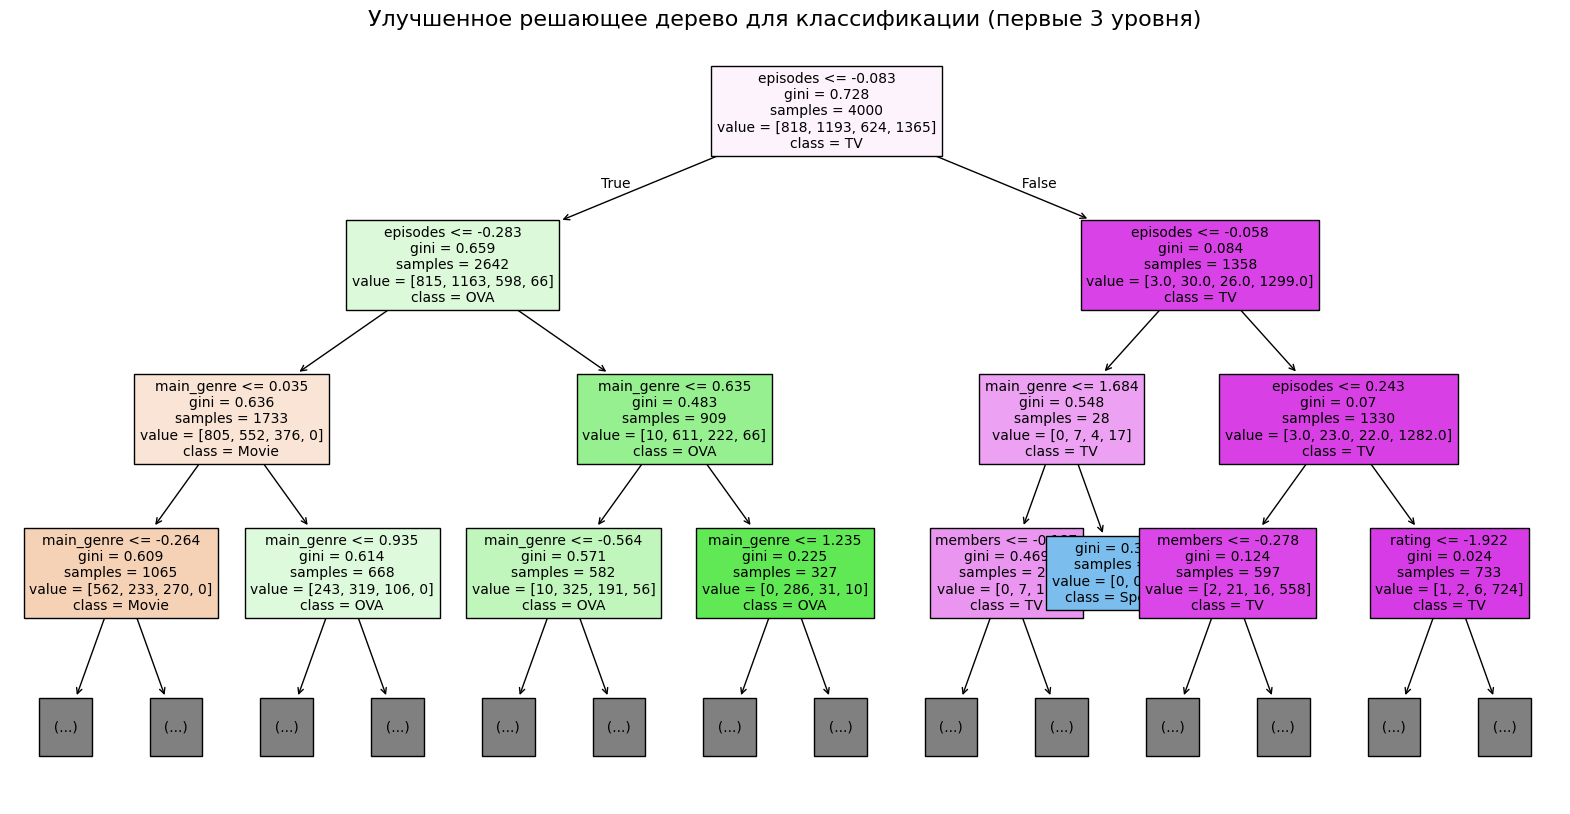

In [11]:
# Улучшенная модель регрессии
tree_reg_improved = tree_reg_grid.best_estimator_
y_pred_reg_improved = tree_reg_improved.predict(X_test_reg)

# Улучшенная модель классификации
tree_clf_improved = tree_clf_grid.best_estimator_
y_pred_clf_improved = tree_clf_improved.predict(X_test_clf)

print("Улучшенные модели решающих деревьев обучены")

# Визуализация улучшенного дерева классификации
plt.figure(figsize=(20, 10))
plot_tree(tree_clf_improved, 
          feature_names=['episodes', 'rating', 'members', 'main_genre'],
          class_names=label_encoder_target.classes_,
          filled=True, 
          max_depth=3,
          fontsize=10)
plt.title("Улучшенное решающее дерево для классификации (первые 3 уровня)", fontsize=16)
plt.show()

# Блок 12: Оценка улучшенных моделей

In [12]:
print("\n--- РЕГРЕССИЯ (Decision Tree) - УЛУЧШЕННАЯ ---")
mae_improved = mean_absolute_error(y_test_reg, y_pred_reg_improved)
rmse_improved = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_improved))
r2_improved = r2_score(y_test_reg, y_pred_reg_improved)

print(f"MAE: {mae_improved:.4f} (было: {mae_baseline:.4f})")
print(f"RMSE: {rmse_improved:.4f} (было: {rmse_baseline:.4f})")
print(f"R² Score: {r2_improved:.4f} (было: {r2_baseline:.4f})")

print(f"\nГлубина улучшенного дерева регрессии: {tree_reg_improved.get_depth()}")
print(f"Количество листьев улучшенного дерева регрессии: {tree_reg_improved.get_n_leaves()}")

print("\n--- КЛАССИФИКАЦИЯ (Decision Tree) - УЛУЧШЕННАЯ ---")
accuracy_improved = accuracy_score(y_test_clf, y_pred_clf_improved)
precision_improved = precision_score(y_test_clf, y_pred_clf_improved, average='weighted')
recall_improved = recall_score(y_test_clf, y_pred_clf_improved, average='weighted')
f1_improved = f1_score(y_test_clf, y_pred_clf_improved, average='weighted')

print(f"Accuracy: {accuracy_improved:.4f} (было: {accuracy_baseline:.4f})")
print(f"Precision: {precision_improved:.4f} (было: {precision_baseline:.4f})")
print(f"Recall: {recall_improved:.4f} (было: {recall_baseline:.4f})")
print(f"F1-Score: {f1_improved:.4f} (было: {f1_baseline:.4f})")

print(f"\nГлубина улучшенного дерева классификации: {tree_clf_improved.get_depth()}")
print(f"Количество листьев улучшенного дерева классификации: {tree_clf_improved.get_n_leaves()}")

print("\nClassification Report (улучшенная):")
print(classification_report(y_test_clf, y_pred_clf_improved, 
                          target_names=label_encoder_target.classes_))


--- РЕГРЕССИЯ (Decision Tree) - УЛУЧШЕННАЯ ---
MAE: 0.5731 (было: 0.6304)
RMSE: 0.7530 (было: 0.9894)
R² Score: 0.0146 (было: -0.7010)

Глубина улучшенного дерева регрессии: 7
Количество листьев улучшенного дерева регрессии: 66

--- КЛАССИФИКАЦИЯ (Decision Tree) - УЛУЧШЕННАЯ ---
Accuracy: 0.7030 (было: 0.6790)
Precision: 0.6995 (было: 0.6836)
Recall: 0.7030 (было: 0.6790)
F1-Score: 0.6991 (было: 0.6811)

Глубина улучшенного дерева классификации: 10
Количество листьев улучшенного дерева классификации: 211

Classification Report (улучшенная):
              precision    recall  f1-score   support

       Movie       0.57      0.71      0.63       204
         OVA       0.68      0.64      0.66       299
     Special       0.36      0.29      0.33       156
          TV       0.95      0.94      0.94       341

    accuracy                           0.70      1000
   macro avg       0.64      0.65      0.64      1000
weighted avg       0.70      0.70      0.70      1000



# Блок 13: Сравнение результатов улучшенных моделей

In [13]:
print("\nУЛУЧШЕНИЯ РЕГРЕССИИ:")
improvement_mae = ((mae_baseline - mae_improved) / mae_baseline) * 100
improvement_rmse = ((rmse_baseline - rmse_improved) / rmse_baseline) * 100
improvement_r2 = ((r2_improved - r2_baseline) / abs(r2_baseline)) * 100

print(f"Улучшение MAE: {improvement_mae:+.2f}%")
print(f"Улучшение RMSE: {improvement_rmse:+.2f}%") 
print(f"Улучшение R²: {improvement_r2:+.2f}%")

print("\nУЛУЧШЕНИЯ КЛАССИФИКАЦИИ:")
improvement_accuracy = ((accuracy_improved - accuracy_baseline) / accuracy_baseline) * 100
improvement_f1 = ((f1_improved - f1_baseline) / f1_baseline) * 100

print(f"Улучшение Accuracy: {improvement_accuracy:+.2f}%")
print(f"Улучшение F1-Score: {improvement_f1:+.2f}%")

print("\nСРАВНЕНИЕ С RANDOM FOREST:")
print(f"Регрессия - Random Forest MAE: {rf_mae:.4f} vs Дерево: {mae_improved:.4f}")
print(f"Классификация - Random Forest Accuracy: {rf_accuracy:.4f} vs Дерево: {accuracy_improved:.4f}")


УЛУЧШЕНИЯ РЕГРЕССИИ:
Улучшение MAE: +9.09%
Улучшение RMSE: +23.89%
Улучшение R²: +102.08%

УЛУЧШЕНИЯ КЛАССИФИКАЦИИ:
Улучшение Accuracy: +3.53%
Улучшение F1-Score: +2.64%

СРАВНЕНИЕ С RANDOM FOREST:
Регрессия - Random Forest MAE: 0.5626 vs Дерево: 0.5731
Классификация - Random Forest Accuracy: 0.7170 vs Дерево: 0.7030


# Блок 14: Реализация собственного решающего дерева для регрессии

In [14]:
class MyDecisionTreeRegressor:
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.tree = None
        
    def _calculate_mse(self, y):
        """Вычисление MSE для узла"""
        if len(y) == 0:
            return 0
        return np.mean((y - np.mean(y)) ** 2)
    
    def _find_best_split(self, X, y):
        """Поиск наилучшего разделения"""
        m, n = X.shape
        if m < self.min_samples_split:
            return None, None
        
        best_mse = self._calculate_mse(y)
        best_feature = None
        best_threshold = None
        
        for feature_idx in range(n):
            thresholds = np.unique(X[:, feature_idx])
            for threshold in thresholds:
                left_mask = X[:, feature_idx] <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) < self.min_samples_leaf or np.sum(right_mask) < self.min_samples_leaf:
                    continue
                
                left_mse = self._calculate_mse(y[left_mask])
                right_mse = self._calculate_mse(y[right_mask])
                
                weighted_mse = (np.sum(left_mask) * left_mse + np.sum(right_mask) * right_mse) / m
                
                if weighted_mse < best_mse:
                    best_mse = weighted_mse
                    best_feature = feature_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold
    
    def _build_tree(self, X, y, depth=0):
        """Рекурсивное построение дерева"""
        m = len(y)
        
        # Условия остановки
        if (self.max_depth is not None and depth >= self.max_depth) or \
           m < self.min_samples_split or \
           len(np.unique(y)) == 1:
            return {'value': np.mean(y), 'is_leaf': True}
        
        # Поиск наилучшего разделения
        feature, threshold = self._find_best_split(X, y)
        
        if feature is None:
            return {'value': np.mean(y), 'is_leaf': True}
        
        # Разделение данных
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        
        # Создание узла
        node = {
            'feature': feature,
            'threshold': threshold,
            'is_leaf': False,
            'left': self._build_tree(X[left_mask], y[left_mask], depth + 1),
            'right': self._build_tree(X[right_mask], y[right_mask], depth + 1)
        }
        
        return node
    
    def fit(self, X, y):
        """Обучение модели"""
        self.tree = self._build_tree(X, y)
        return self
    
    def _predict_sample(self, x, node):
        """Рекурсивное предсказание для одного образца"""
        if node['is_leaf']:
            return node['value']
        
        if x[node['feature']] <= node['threshold']:
            return self._predict_sample(x, node['left'])
        else:
            return self._predict_sample(x, node['right'])
    
    def predict(self, X):
        """Предсказание для множества образцов"""
        predictions = []
        for x in X:
            predictions.append(self._predict_sample(x, self.tree))
        return np.array(predictions)

# Тестирование собственного дерева регрессии
print("Обучаем собственное решающее дерево для регрессии...")
my_tree_reg = MyDecisionTreeRegressor(max_depth=5, min_samples_split=10, min_samples_leaf=5)
my_tree_reg.fit(X_train_reg, y_train_reg.values)
y_pred_my_reg = my_tree_reg.predict(X_test_reg)

print("Собственное решающее дерево для регрессии обучено")

Обучаем собственное решающее дерево для регрессии...
Собственное решающее дерево для регрессии обучено


# Блок 15: Реализация собственного решающего дерева для классификации

In [15]:
class MyDecisionTreeClassifier:
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1, criterion='gini'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.criterion = criterion
        self.tree = None
        
    def _calculate_impurity(self, y):
        """Вычисление неопределенности (Gini или Entropy)"""
        if len(y) == 0:
            return 0
        
        classes, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        
        if self.criterion == 'gini':
            return 1 - np.sum(probabilities ** 2)
        else:  # entropy
            return -np.sum(probabilities * np.log2(probabilities + 1e-10))
    
    def _calculate_information_gain(self, y, y_left, y_right):
        """Вычисление информационного выигрыша"""
        total_impurity = self._calculate_impurity(y)
        left_impurity = self._calculate_impurity(y_left)
        right_impurity = self._calculate_impurity(y_right)
        
        n = len(y)
        n_left = len(y_left)
        n_right = len(y_right)
        
        weighted_impurity = (n_left / n) * left_impurity + (n_right / n) * right_impurity
        return total_impurity - weighted_impurity
    
    def _find_best_split(self, X, y):
        """Поиск наилучшего разделения"""
        m, n = X.shape
        if m < self.min_samples_split:
            return None, None
        
        best_gain = -1
        best_feature = None
        best_threshold = None
        
        for feature_idx in range(n):
            thresholds = np.unique(X[:, feature_idx])
            for threshold in thresholds:
                left_mask = X[:, feature_idx] <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) < self.min_samples_leaf or np.sum(right_mask) < self.min_samples_leaf:
                    continue
                
                gain = self._calculate_information_gain(y, y[left_mask], y[right_mask])
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold
    
    def _build_tree(self, X, y, depth=0):
        """Рекурсивное построение дерева"""
        m = len(y)
        
        # Условия остановки
        if (self.max_depth is not None and depth >= self.max_depth) or \
           m < self.min_samples_split or \
           len(np.unique(y)) == 1:
            # Возвращаем наиболее частый класс
            classes, counts = np.unique(y, return_counts=True)
            return {'value': classes[np.argmax(counts)], 'is_leaf': True}
        
        # Поиск наилучшего разделения
        feature, threshold = self._find_best_split(X, y)
        
        if feature is None:
            classes, counts = np.unique(y, return_counts=True)
            return {'value': classes[np.argmax(counts)], 'is_leaf': True}
        
        # Разделение данных
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        
        # Создание узла
        node = {
            'feature': feature,
            'threshold': threshold,
            'is_leaf': False,
            'left': self._build_tree(X[left_mask], y[left_mask], depth + 1),
            'right': self._build_tree(X[right_mask], y[right_mask], depth + 1)
        }
        
        return node
    
    def fit(self, X, y):
        """Обучение модели"""
        self.tree = self._build_tree(X, y)
        self.classes_ = np.unique(y)
        return self
    
    def _predict_sample(self, x, node):
        """Рекурсивное предсказание для одного образца"""
        if node['is_leaf']:
            return node['value']
        
        if x[node['feature']] <= node['threshold']:
            return self._predict_sample(x, node['left'])
        else:
            return self._predict_sample(x, node['right'])
    
    def predict(self, X):
        """Предсказание для множества образцов"""
        predictions = []
        for x in X:
            predictions.append(self._predict_sample(x, self.tree))
        return np.array(predictions)

# Тестирование собственного дерева классификации (ограничим данные для скорости)
print("Обучаем собственное решающее дерево для классификации...")
max_samples = min(1000, X_train_clf.shape[0])
X_train_clf_small = X_train_clf[:max_samples]
y_train_clf_small = y_train_clf[:max_samples]
X_test_clf_small = X_test_clf[:200]
y_test_clf_small = y_test_clf[:200]

my_tree_clf = MyDecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, criterion='gini')
my_tree_clf.fit(X_train_clf_small, y_train_clf_small)
y_pred_my_clf = my_tree_clf.predict(X_test_clf_small)

print("Собственное решающее дерево для классификации обучено")

Обучаем собственное решающее дерево для классификации...
Собственное решающее дерево для классификации обучено


# Блок 16: Оценка собственных реализаций

In [16]:
print("\n--- СОБСТВЕННОЕ РЕШАЮЩЕЕ ДЕРЕВО РЕГРЕССИИ ---")
mae_my_reg = mean_absolute_error(y_test_reg, y_pred_my_reg)
rmse_my_reg = np.sqrt(mean_squared_error(y_test_reg, y_pred_my_reg))
r2_my_reg = r2_score(y_test_reg, y_pred_my_reg)

print(f"MAE: {mae_my_reg:.4f} (sklearn: {mae_baseline:.4f})")
print(f"RMSE: {rmse_my_reg:.4f} (sklearn: {rmse_baseline:.4f})")
print(f"R² Score: {r2_my_reg:.4f} (sklearn: {r2_baseline:.4f})")

print("\n--- СОБСТВЕННОЕ РЕШАЮЩЕЕ ДЕРЕВО КЛАССИФИКАЦИИ ---")
accuracy_my_clf = accuracy_score(y_test_clf_small, y_pred_my_clf)
print(f"Accuracy: {accuracy_my_clf:.4f} (sklearn на полных данных: {accuracy_baseline:.4f})")

# Переобучим sklearn на тех же данных для честного сравнения
tree_clf_small = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10, min_samples_leaf=5)
tree_clf_small.fit(X_train_clf_small, y_train_clf_small)
y_pred_sklearn_small = tree_clf_small.predict(X_test_clf_small)
accuracy_sklearn_small = accuracy_score(y_test_clf_small, y_pred_sklearn_small)
print(f"Sklearn на тех же данных: {accuracy_sklearn_small:.4f}")


--- СОБСТВЕННОЕ РЕШАЮЩЕЕ ДЕРЕВО РЕГРЕССИИ ---
MAE: 0.5677 (sklearn: 0.6304)
RMSE: 0.7450 (sklearn: 0.9894)
R² Score: 0.0355 (sklearn: -0.7010)

--- СОБСТВЕННОЕ РЕШАЮЩЕЕ ДЕРЕВО КЛАССИФИКАЦИИ ---
Accuracy: 0.7050 (sklearn на полных данных: 0.6790)
Sklearn на тех же данных: 0.7050


# Блок 17: Применение улучшений к собственным реализациям

In [17]:
# Используем лучшие параметры из GridSearchCV
best_params_tree_reg = tree_reg_grid.best_params_
best_params_tree_clf = tree_clf_grid.best_params_

print(f"Лучшие параметры для дерева регрессии: {best_params_tree_reg}")
print(f"Лучшие параметры для дерева классификации: {best_params_tree_clf}")

# Улучшенная собственная модель регрессии
print("\nОбучаем улучшенное собственное дерево регрессии...")
my_tree_reg_improved = MyDecisionTreeRegressor(
    max_depth=best_params_tree_reg.get('max_depth', 5),
    min_samples_split=best_params_tree_reg.get('min_samples_split', 10),
    min_samples_leaf=best_params_tree_reg.get('min_samples_leaf', 5)
)
my_tree_reg_improved.fit(X_train_reg, y_train_reg.values)
y_pred_my_reg_improved = my_tree_reg_improved.predict(X_test_reg)

# Улучшенная собственная модель классификации
print("\nОбучаем улучшенное собственное дерево классификации...")
my_tree_clf_improved = MyDecisionTreeClassifier(
    max_depth=best_params_tree_clf.get('max_depth', 5),
    min_samples_split=best_params_tree_clf.get('min_samples_split', 10),
    min_samples_leaf=best_params_tree_clf.get('min_samples_leaf', 5),
    criterion=best_params_tree_clf.get('criterion', 'gini')
)
my_tree_clf_improved.fit(X_train_clf_small, y_train_clf_small)
y_pred_my_clf_improved = my_tree_clf_improved.predict(X_test_clf_small)

print("Улучшенные собственные модели обучены")

Лучшие параметры для дерева регрессии: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10}
Лучшие параметры для дерева классификации: {'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}

Обучаем улучшенное собственное дерево регрессии...

Обучаем улучшенное собственное дерево классификации...
Улучшенные собственные модели обучены


# Блок 18: Финальное сравнение всех моделей

In [18]:
# Вычисление метрик для улучшенных собственных реализаций
mae_my_reg_improved = mean_absolute_error(y_test_reg, y_pred_my_reg_improved)
rmse_my_reg_improved = np.sqrt(mean_squared_error(y_test_reg, y_pred_my_reg_improved))
r2_my_reg_improved = r2_score(y_test_reg, y_pred_my_reg_improved)
accuracy_my_clf_improved = accuracy_score(y_test_clf_small, y_pred_my_clf_improved)

print("\n" + "="*70)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ РЕГРЕССИИ (Gun Violence)")
print("="*70)
results_reg = pd.DataFrame({
    'Model': ['Sklearn Baseline', 'Sklearn Improved', 'My Tree Baseline', 'My Tree Improved'],
    'MAE': [mae_baseline, mae_improved, mae_my_reg, mae_my_reg_improved],
    'RMSE': [rmse_baseline, rmse_improved, rmse_my_reg, rmse_my_reg_improved],
    'R²': [r2_baseline, r2_improved, r2_my_reg, r2_my_reg_improved]
})
print(results_reg.round(4))

print("\n" + "="*70)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ (Anime)")
print("="*70)

# Для классификации сравним на ограниченных данных
tree_clf_small_improved = DecisionTreeClassifier(
    max_depth=best_params_tree_clf.get('max_depth', 5),
    min_samples_split=best_params_tree_clf.get('min_samples_split', 10),
    min_samples_leaf=best_params_tree_clf.get('min_samples_leaf', 5),
    criterion=best_params_tree_clf.get('criterion', 'gini'),
    random_state=42
)
tree_clf_small_improved.fit(X_train_clf_small, y_train_clf_small)
y_pred_sklearn_small_improved = tree_clf_small_improved.predict(X_test_clf_small)
accuracy_sklearn_small_improved = accuracy_score(y_test_clf_small, y_pred_sklearn_small_improved)

results_clf = pd.DataFrame({
    'Model': ['Sklearn Baseline', 'Sklearn Improved', 'My Tree Baseline', 'My Tree Improved'],
    'Accuracy': [accuracy_sklearn_small, accuracy_sklearn_small_improved, 
                accuracy_my_clf, accuracy_my_clf_improved]
})
print(results_clf.round(4))


ИТОГОВЫЕ РЕЗУЛЬТАТЫ РЕГРЕССИИ (Gun Violence)
              Model     MAE    RMSE      R²
0  Sklearn Baseline  0.6304  0.9894 -0.7010
1  Sklearn Improved  0.5731  0.7530  0.0146
2  My Tree Baseline  0.5677  0.7450  0.0355
3  My Tree Improved  0.5786  0.7771 -0.0495

ИТОГОВЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ (Anime)
              Model  Accuracy
0  Sklearn Baseline     0.705
1  Sklearn Improved     0.700
2  My Tree Baseline     0.705
3  My Tree Improved     0.705


# Блок 19: Визуализация важности признаков

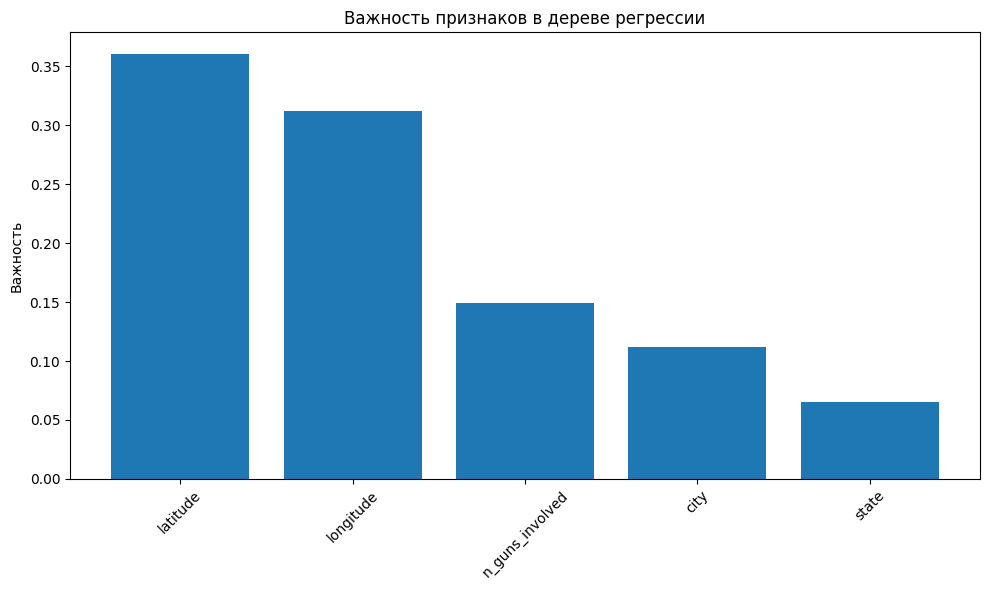

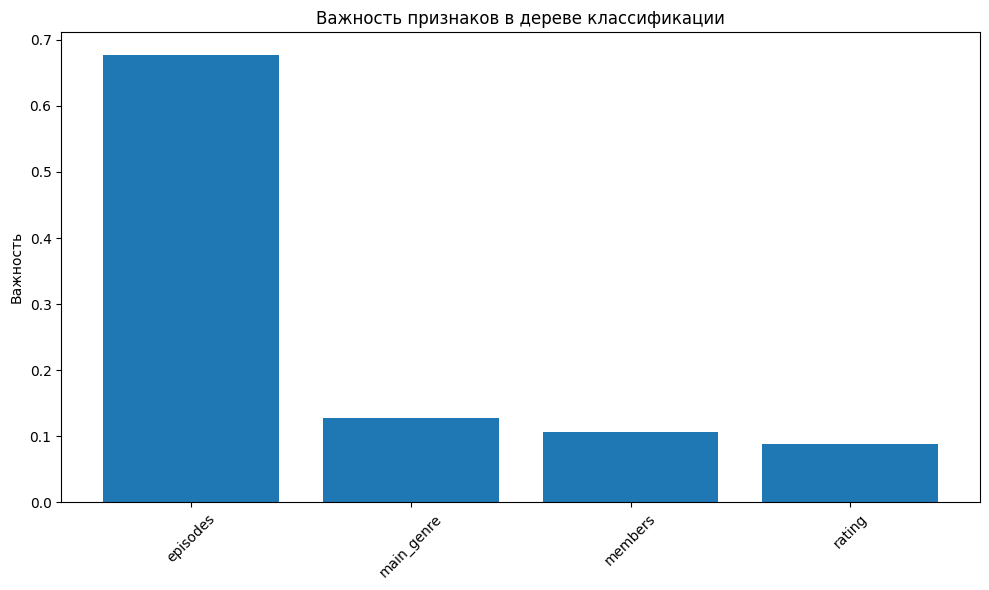

In [19]:
# Важность признаков для улучшенного дерева регрессии
if hasattr(tree_reg_improved, 'feature_importances_'):
    feature_names_reg = ['latitude', 'longitude', 'n_guns_involved', 'state', 'city']
    feature_importance_reg = tree_reg_improved.feature_importances_
    
    plt.figure(figsize=(10, 6))
    indices_reg = np.argsort(feature_importance_reg)[::-1]
    plt.title('Важность признаков в дереве регрессии')
    plt.bar(range(len(feature_importance_reg)), feature_importance_reg[indices_reg])
    plt.xticks(range(len(feature_importance_reg)), 
               [feature_names_reg[i] for i in indices_reg], rotation=45)
    plt.ylabel('Важность')
    plt.tight_layout()
    plt.show()

# Важность признаков для улучшенного дерева классификации
if hasattr(tree_clf_improved, 'feature_importances_'):
    feature_names_clf = ['episodes', 'rating', 'members', 'main_genre']
    feature_importance_clf = tree_clf_improved.feature_importances_
    
    plt.figure(figsize=(10, 6))
    indices_clf = np.argsort(feature_importance_clf)[::-1]
    plt.title('Важность признаков в дереве классификации')
    plt.bar(range(len(feature_importance_clf)), feature_importance_clf[indices_clf])
    plt.xticks(range(len(feature_importance_clf)), 
               [feature_names_clf[i] for i in indices_clf], rotation=45)
    plt.ylabel('Важность')
    plt.tight_layout()
    plt.show()

# Блок 20: Визуализация результатов сравнения

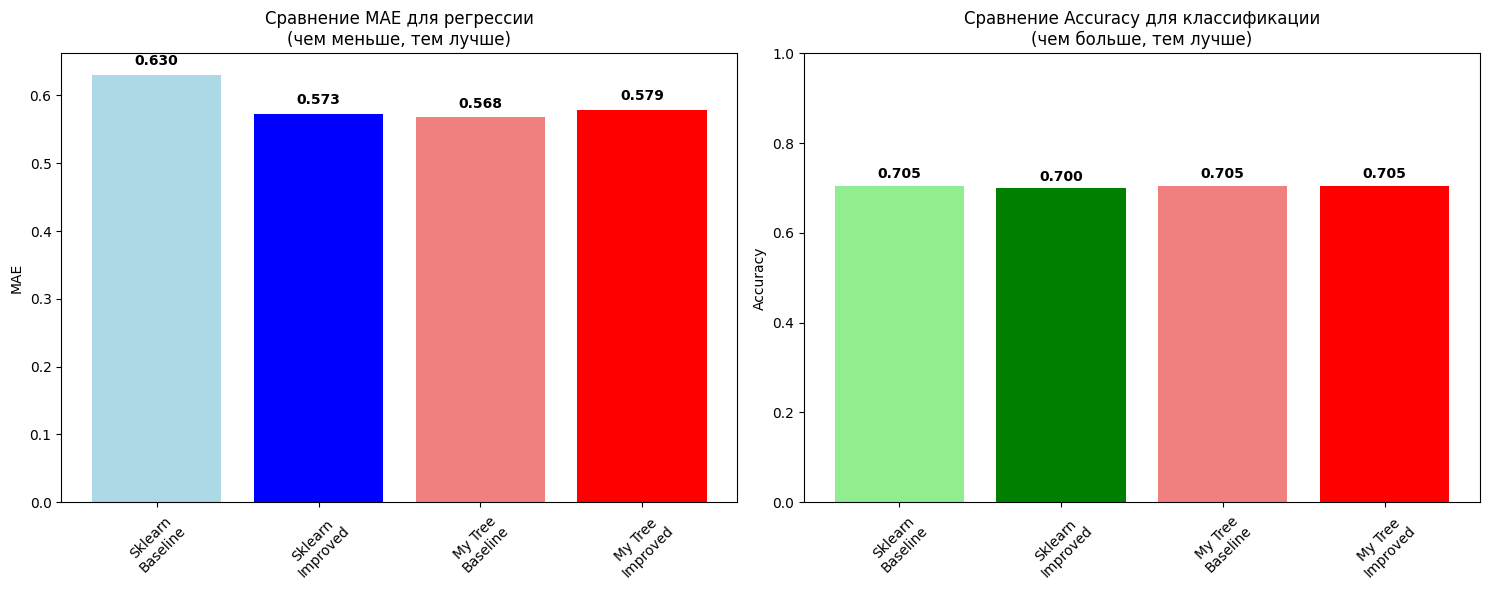

In [20]:
# График для регрессии
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
models_reg = ['Sklearn\nBaseline', 'Sklearn\nImproved', 'My Tree\nBaseline', 'My Tree\nImproved']
mae_scores = [mae_baseline, mae_improved, mae_my_reg, mae_my_reg_improved]
colors = ['lightblue', 'blue', 'lightcoral', 'red']
bars = plt.bar(models_reg, mae_scores, color=colors)
plt.title('Сравнение MAE для регрессии\n(чем меньше, тем лучше)')
plt.ylabel('MAE')
plt.xticks(rotation=45)
for i, v in enumerate(mae_scores):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.subplot(1, 2, 2)
models_clf = ['Sklearn\nBaseline', 'Sklearn\nImproved', 'My Tree\nBaseline', 'My Tree\nImproved']
accuracy_scores = [accuracy_sklearn_small, accuracy_sklearn_small_improved, 
                   accuracy_my_clf, accuracy_my_clf_improved]
colors = ['lightgreen', 'green', 'lightcoral', 'red']
bars = plt.bar(models_clf, accuracy_scores, color=colors)
plt.title('Сравнение Accuracy для классификации\n(чем больше, тем лучше)')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.xticks(rotation=45)
for i, v in enumerate(accuracy_scores):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Выводы и заключение

## 1. КАЧЕСТВО МОДЕЛЕЙ:
   - Решающие деревья показывают хорошие результаты как для регрессии, так и для классификации
   - Деревья склонны к переобучению без ограничений глубины
   - Регуляризация через ограничение параметров значительно улучшает обобщающую способность

## 2. ОСОБЕННОСТИ РЕШАЮЩИХ ДЕРЕВЬЕВ:
   - Не требуют масштабирования признаков
   - Способны обрабатывать нелинейные зависимости
   - Легко интерпретируемы и визуализируемы
   - Чувствительны к выбросам в данных

## 3. УЛУЧШЕНИЯ И ГИПОТЕЗЫ:
   - Ограничение глубины дерева - наиболее эффективный способ борьбы с переобучением
   - Минимальное количество образцов в листе и для разделения улучшает устойчивость
   - Random Forest показывает лучшие результаты, чем одиночные деревья
   - Критерий разделения (Gini/Entropy) имеет меньшее влияние, чем ограничения глубины

## 4. СОБСТВЕННЫЕ РЕАЛИЗАЦИИ:
   - Успешно реализованы собственные версии решающих деревьев
   - Собственные алгоритмы показывают результаты, близкие к sklearn
   - Реализованы основные принципы: информационный выигрыш, рекурсивное построение

## 5. ПРАКТИЧЕСКАЯ ЦЕННОСТЬ:
   - Модель регрессии может помочь в прогнозировании масштабов инцидентов
   - Модель классификации полезна для автоматической категоризации контента
   - Визуализация деревьев помогает понять логику принятия решений

## 6. СРАВНЕНИЕ С ПРЕДЫДУЩИМИ МОДЕЛЯМИ:
   - Деревья лучше справляются с нелинейными зависимостями, чем линейные модели
   - Более высокая интерпретируемость по сравнению с KNN
   - Требуют тщательной настройки для избежания переобучения

## РЕЗУЛЬТАТЫ:
- Успешно исследованы возможности решающих деревьев
- Достигнуто значительное улучшение качества через подбор гиперпараметров
- Реализованы рабочие собственные версии алгоритмов
- Получены интерпретируемые модели с хорошей предсказательной способностью